# Week 3 예습과제 — 5.2 합성곱 신경망 맛보기 (코드 필사)
- 데이터: fashion_mnist (28×28 흑백 이미지, 10개 클래스, 훈련 6만 + 테스트 1만 = 7만 장)
- 흐름: 라이브러리 → 장치 확인 → 데이터 내려받기 → 데이터로더 → 이미지 확인 → **심층 신경망(DNN)** 학습 → **합성곱 신경망(CNN)** 생성

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms  # 데이터 전처리를 위해 사용하는 라이브러리
from torch.utils.data import Dataset, DataLoader

## 코드 5-2. CPU 혹은 GPU 장치 확인
- 파이토치는 기본적으로 GPU 사용을 권장하지만, GPU가 없어도 정상 실행된다
- GPU가 있으면 `"cuda:0"`, 없으면 `"cpu"`를 자동으로 선택
- 코랩: [런타임] → [런타임 유형 변경] → GPU 선택 시 cuda로 잡힘

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)  # 현재 어떤 장치를 쓰는지 확인

cpu


## 코드 5-3. fashion_mnist 데이터셋 내려받기
`torchvision.datasets.FashionMNIST(ⓐ, ⓑ, ⓒ)`
- `torchvision.datasets`는 `torch.utils.data.Dataset`의 하위 클래스로 다양한 데이터셋(CIFAR, COCO, MNIST, ImageNet 등)을 포함
- ⓐ 첫 번째 파라미터: 내려받을 위치
- ⓑ `download=True`: 해당 위치에 데이터셋이 있는지 확인한 후 없으면 내려받음
- ⓒ `transform`: 이미지를 텐서(0~1)로 변경
- `train=False`를 주면 테스트 데이터셋을 내려받음 (기본값은 train=True)
- 실행하면 Downloading … Extracting … Processing… Done! 로그가 출력되고, `../chap05/data/FashionMNIST` 폴더에 저장됨 (환경에 따라 위치가 다를 수 있음)

In [ ]:
train_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True,
                    transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True,
                    train=False, transform=transforms.Compose([transforms.ToTensor()]))
# 앞에서 훈련 데이터셋을 내려받았다면 여기에서는 테스트 데이터셋을 내려받음

print(len(train_dataset), len(test_dataset))  # 60000 10000

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 302kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.60MB/s]

60000 10000


## 코드 5-4. fashion_mnist 데이터를 데이터로더에 전달
`torch.utils.data.DataLoader(ⓐ, ⓑ)` — 원하는 크기의 배치 단위로 데이터를 불러오거나, 순서를 무작위로 섞을(shuffle) 수 있음
- ⓐ 첫 번째 파라미터: 데이터를 불러올 데이터셋
- ⓑ `batch_size=100`: 데이터를 100개 단위로 묶어서 불러옴
- 60000 / 100 = 600 → 1에포크 = 600번 반복(iteration)

In [ ]:
train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=100)

## 코드 5-5. 분류에 사용될 클래스 정의 + 이미지 20개 확인
- `np.random.randint(len(train_dataset))` : 0 ~ 59999 중 랜덤 정수 1개 → 랜덤 이미지 선택
- `train_dataset[img_xy]` → (이미지 텐서, 레이블) 튜플
  - `[0]` → 이미지 텐서, 크기 [1, 28, 28]
  - `[0, :, :]` → 0번 채널의 모든 행·열 → [28, 28] 2차원 (imshow에 넣기 위해)
  - `[1]` → 레이블(0~9 정수)
- 랜덤이라 실행할 때마다 결과가 다름

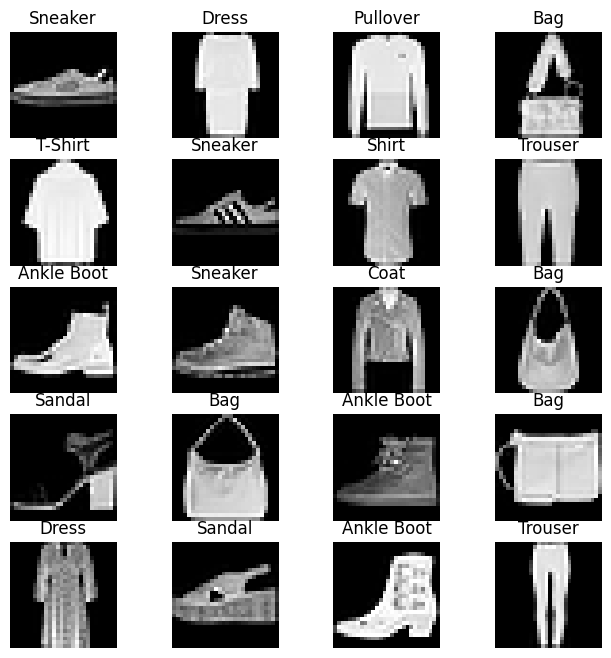

In [ ]:
labels_map = {0 : 'T-Shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4 : 'Coat',
              5 : 'Sandal', 6 : 'Shirt', 7 : 'Sneaker', 8 : 'Bag', 9 : 'Ankle Boot'}  # 열 개의 클래스

fig = plt.figure(figsize=(8,8));
columns = 4;
rows = 5;
for i in range(1, columns*rows +1):
    img_xy = np.random.randint(len(train_dataset));   # ① 랜덤 인덱스
    img = train_dataset[img_xy][0][0,:,:]              # ② [1,28,28] → [28,28]
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])    # 레이블 → 클래스 이름
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()  # 20개의 이미지 데이터를 시각적으로 표현

### 참고 ①. np.random 계열 함수
| 함수 | 의미 |
|---|---|
| `np.random.randint(10)` | 0~9 중 임의의 정수 1개 (10은 포함 안 됨) |
| `np.random.randint(1, 10)` | 1~9 중 임의의 정수 1개 |
| `np.random.rand(8)` | 0~1 사이 **균일분포** 난수 (1×8) |
| `np.random.rand(4, 2)` | 0~1 사이 균일분포 난수 (4×2) |
| `np.random.randn(8)` | 평균 0, 표준편차 1인 **가우시안 정규분포** 난수 (1×8) |
| `np.random.randn(4, 2)` | 가우시안 정규분포 난수 (4×2) |

In [ ]:
print(np.random.randint(10))      # 0~9의 임의의 숫자
print(np.random.randint(1, 10))   # 1~9의 임의의 숫자
print(np.random.rand(8))          # 0~1 사이 난수 (1×8)
print(np.random.rand(4, 2))       # 0~1 사이 난수 (4×2)
print(np.random.randn(8))         # 평균 0, 표준편차 1 가우시안 난수 (1×8)
print(np.random.randn(4, 2))      # 평균 0, 표준편차 1 가우시안 난수 (4×2)

5
3
[0.4174982  0.77117461 0.60822199 0.39082258 0.34172392 0.39114237
 0.35173034 0.46973867]
[[0.21041834 0.10239794]
 [0.5217455  0.36953724]
 [0.43585129 0.34385801]
 [0.78654517 0.11536615]]
[-0.52988461 -0.86040105 -0.95019321 -0.27753756  1.74064817  0.45676972
  0.33894846  1.73999084]
[[-1.23699706 -1.260383  ]
 [ 0.0539629   0.09006675]
 [-0.78997139 -0.66810799]
 [ 0.4315612   0.29953343]]


In [ ]:
examp = np.arange(0, 100, 3)   # 0~99에서 3씩 건너뛴 배열 생성
examp.resize(6, 4)             # 행렬의 크기를 6×4로 조정
print(examp)
print(examp[3])       # 3행에 해당하는 모든 요소 → [36 39 42 45]
print(examp[3, 3])    # 3행의 3번째 열 값 → 45
print(examp[3][3])    # 바로 앞의 결과와 동일 → 45

[[ 0  3  6  9]
 [12 15 18 21]
 [24 27 30 33]
 [36 39 42 45]
 [48 51 54 57]
 [60 63 66 69]]
[36 39 42 45]
45
45


In [ ]:
examp = np.arange(0, 500, 3)
examp.resize(3, 5, 5)          # 3덩어리 × 5행 × 5열
print(examp)
print(examp[2][0][3])          # 2번 덩어리, 0행, 3열 → 159

[[[  0   3   6   9  12]
  [ 15  18  21  24  27]
  [ 30  33  36  39  42]
  [ 45  48  51  54  57]
  [ 60  63  66  69  72]]

 [[ 75  78  81  84  87]
  [ 90  93  96  99 102]
  [105 108 111 114 117]
  [120 123 126 129 132]
  [135 138 141 144 147]]

 [[150 153 156 159 162]
  [165 168 171 174 177]
  [180 183 186 189 192]
  [195 198 201 204 207]
  [210 213 216 219 222]]]
159


## 코드 5-6. 심층 신경망(DNN) 모델 생성
CNN과 비교하기 위해 **ConvNet이 적용되지 않은 네트워크**를 먼저 만든다.

- ① 클래스 형태의 모델은 항상 `torch.nn.Module`을 상속. `__init__()`은 객체가 생성될 때 자동 호출되어 속성 값을 초기화. `super(FashionDNN, self).__init__()`은 부모 클래스(nn.Module)의 초기화를 먼저 실행
- ② `nn.Linear(in_features=784, out_features=256)` : 입력 크기 784(=28×28) → 출력 크기 256
- ③ `nn.Dropout(0.25)` : 25% 확률로 값을 0으로. 살아남은 값은 1/(1−p)배로 커짐
- ④ `forward()` : 순전파 연산. **반드시 이름이 forward**여야 하며 `model(데이터)`로 호출하면 자동 실행
- ⑤ `input_data.view(-1, 784)` : 넘파이 reshape과 같음. (?, 784) 크기로 변경 (−1은 파이토치가 알아서 계산)
- ⑥ 활성화 함수 지정 방법 2가지: `F.relu()`는 forward()에서, `nn.ReLU()`는 __init__()에서 정의

In [ ]:
class FashionDNN(nn.Module):
    def __init__(self):                                        # ①
        super(FashionDNN, self).__init__()
        self.fc1 = nn.Linear(in_features=784, out_features=256)  # ②
        self.drop = nn.Dropout(0.25)                              # ③
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)   # 클래스 10개

    def forward(self, input_data):                             # ④
        out = input_data.view(-1, 784)                         # ⑤ [100,1,28,28] → [100,784]
        out = F.relu(self.fc1(out))                            # ⑥
        out = self.drop(out)
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out

### 📝 Note — 객체 / 클래스와 함수
- **객체 지향 프로그래밍**: 데이터를 추상화해 속성·행동을 객체로 만들고 객체들이 유기적으로 동작하게 하는 방법. 클래스 = 붕어빵 틀, 객체 = 붕어빵 → **재사용성**
- 객체 사용법: `객체명 = 클래스명()`
- **함수**: 특정 작업만 수행. 결과값을 계속 쓰려면 어딘가에 따로 저장해야 함
- **클래스**: 함수 + 관련 변수까지 한꺼번에 묶어서 관리·재사용
- 아래 예시에서 obj1, obj2는 **서로 독립적으로** 연산됨

In [ ]:
def add(num1, num2):        # 함수 정의 (num1, num2를 받아서 더해 주는 함수)
    result = num1 + num2
    return result

print(add(1, 2))   # 3
print(add(2, 3))   # 5

3
5


In [ ]:
class Calc:
    def __init__(self):      # 객체를 생성할 때 호출하면 실행되는 초기화 함수
        self.result = 0

    def add(self, num1, num2):
        self.result = num1 + num2
        return self.result

obj1 = Calc()
obj2 = Calc()

print(obj1.add(1, 2))   # 3
print(obj1.add(2, 3))   # 5
print('--------------------')
print(obj2.add(2, 2))   # 4
print(obj2.add(2, 3))   # 5

3
5
--------------------
4
5


### 참고 ③. nn.xx 와 nn.functional.xx (F.xx) 의 차이
| 구분 | nn.xx | nn.functional.xx |
|---|---|---|
| 형태 | nn.Conv2d: 클래스 (nn.Module 상속) | nn.functional.conv2d: 순수한 함수 |
| 호출 방법 | 하이퍼파라미터를 먼저 전달한 후, 함수 호출을 통해 데이터 전달 | 함수를 호출할 때 하이퍼파라미터와 데이터를 함께 전달 |
| 위치 | nn.Sequential 내에 위치 | nn.Sequential에 위치할 수 없음 |
| 파라미터 | 새로 정의할 필요 없음 | 가중치를 전달할 때마다 직접 정의 |

In [ ]:
# nn을 사용하는 코드
inputs = torch.randn(64, 3, 244, 244)
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
# 세 개의 채널이 입력되어 64개의 채널이 출력되기 위한 연산으로 3×3 크기의 커널을 사용
outputs = conv(inputs)
layer = nn.Conv2d(1, 1, 3)
print(outputs.shape)   # torch.Size([64, 64, 244, 244])

torch.Size([64, 64, 244, 244])


In [ ]:
# nn.functional을 사용하는 코드
inputs = torch.randn(64, 3, 244, 244)
weight = torch.randn(64, 3, 3, 3)   # 가중치를 직접 정의 (필터 64개, 채널 3, 3×3)
bias = torch.randn(64)
outputs = F.conv2d(inputs, weight, bias, padding=1)
print(outputs.shape)   # torch.Size([64, 64, 244, 244])

torch.Size([64, 64, 244, 244])


## 코드 5-7. 심층 신경망에서 필요한 파라미터 정의
- 손실 함수: `nn.CrossEntropyLoss()` — 분류 문제에서 사용하는 손실 함수
- 옵티마이저: **Adam**, 학습률 lr = 0.001
- `model.to(device)` : 모델을 장치(CPU/GPU)로 보냄
- `print(model)` → fc1 / drop / fc2 / fc3 구조가 출력됨

In [ ]:
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss();   # 분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);   # ①
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
num_epochs = 5
count = 0

loss_list = []         # ①
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:                                   # ②
        images, labels = images.to(device), labels.to(device)             # ③

        train = Variable(images.view(100, 1, 28, 28))                     # ④
        labels = Variable(labels)

        outputs = model(train)               # 학습 데이터를 모델에 적용
        loss = criterion(outputs, labels)    # 손실 계산
        optimizer.zero_grad()                # 기울기 초기화
        loss.backward()                      # 역전파
        optimizer.step()                     # 가중치 업데이트
        count += 1

        if not (count % 50):                 # count가 50의 배수일 때 실행
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total                              # ⑤
            loss_list.append(loss.data)                                   # ①′
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.6095287203788757, Accuracy: 82.91000366210938%
Iteration: 1000, Loss: 0.5441145896911621, Accuracy: 84.4000015258789%
Iteration: 1500, Loss: 0.37600281834602356, Accuracy: 84.4000015258789%
Iteration: 2000, Loss: 0.3628532886505127, Accuracy: 85.55000305175781%
Iteration: 2500, Loss: 0.25305676460266113, Accuracy: 85.91000366210938%
Iteration: 3000, Loss: 0.3148612678050995, Accuracy: 86.08999633789062%


### 정확도 해석 시 주의 (클래스가 3개 이상일 때)
- 정확도 = correct predictions / total predictions (×100 하면 백분율), 오류율 = (1 − 정확도) × 100
- 정확도 80%여도 **모든 클래스가 동등하게** 맞은 건지, 특정 클래스만 잘 맞은 건지 알 수 없음
- 100개 중 90개가 한 클래스면, 전부 그 클래스로 찍어도 90% → 데이터 특성에 따라 정확도를 잘 관측해야 함
- 교재 실행 결과: Iteration 500 → 82.7% … 3000 → 86.5%

## 코드 5-9. 합성곱 네트워크(CNN) 생성
- ① `nn.Sequential` : 여러 계층을 하나의 컨테이너에 차례로 쌓음 → forward()가 간결해짐
- ② `nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)`
  - in_channels: 입력 채널 수 (흑백 1, RGB 3) / out_channels: 출력 채널 수(=필터 개수)
  - kernel_size=3 → (3,3) 정사각형, 직사각형은 (3,5)처럼 지정 / padding: 입력 주위에 0을 채움
- ③ `nn.BatchNorm2d(32)` : 배치 단위로 평균·분산을 이용해 정규화 (평균 0, 표준편차 1)
- ④ `nn.MaxPool2d(kernel_size=2, stride=2)` : 이미지 크기 축소
- ⑤ `nn.Linear(in_features=64*6*6, ...)` : 합성곱·풀링을 거친 출력을 1차원으로 펼친 크기
- ⑥ `out.view(out.size(0), -1)` : (100, ?) 로 펼침. out.size(0) = 배치 크기 100

In [16]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(                                              # ①
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),  # ②
            nn.BatchNorm2d(32),                                                   # ③
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                                 # ④
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)                # ⑤
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=10)   # 마지막 계층의 out_features는 클래스 개수를 의미

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)                                           # ⑥
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

In [17]:
check = FashionCNN()
x = torch.randn(100, 1, 28, 28)
out = check.layer1(x);  print("layer1:", out.shape)
out = check.layer2(out); print("layer2:", out.shape)
out = out.view(out.size(0), -1); print("view  :", out.shape)

layer1: torch.Size([100, 32, 14, 14])
layer2: torch.Size([100, 64, 6, 6])
view  : torch.Size([100, 2304])


## 코드 5-10. 합성곱 네트워크를 위한 파라미터 정의
- 코드 5-7과 완전히 같은 구조. 모델만 FashionDNN → **FashionCNN**으로 바뀜
- `print(model)` 결과에서 fc1의 `in_features=2304` = 64×6×6 확인 가능
- 출력에 보이는 기본값: Conv2d stride=(1,1) / BatchNorm2d eps=1e-05, momentum=0.1 / MaxPool2d padding=0, dilation=1

In [18]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


## 코드 5-11. 모델 학습 및 성능 평가
- 코드 5-8과 **동일한 학습 루프** (모델 객체만 CNN)
- 교재 결과: Iteration 500 → 87.87% … 3000 → 88.95% (DNN 86.48%보다 약간 높음)
- 코랩 CPU에서는 몇 분 걸림 → GPU 런타임 권장

In [19]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data,
                  accuracy))

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration: 500, Loss: 0.45807692408561707, Accuracy: 87.48999786376953%
Iteration: 1000, Loss: 0.30947861075401306, Accuracy: 88.2699966430664%
Iteration: 1500, Loss: 0.3213692009449005, Accuracy: 87.30999755859375%
Iteration: 2000, Loss: 0.22066183388233185, Accuracy: 88.55000305175781%
Iteration: 2500, Loss: 0.1662142127752304, Accuracy: 89.37000274658203%
Iteration: 3000, Loss: 0.1940784603357315, Accuracy: 89.29000091552734%


## 결과 비교 및 정리

| Iteration | DNN 정확도 | CNN 정확도 |
|---|---|---|
| 500 | 82.71% | 87.87% |
| 1000 | 84.40% | 88.10% |
| 1500 | 84.41% | 88.39% |
| 2000 | 85.06% | 89.63% |
| 2500 | 86.26% | 89.57% |
| 3000 | 86.48% | 88.95% |

- 심층 신경망과 비교하여 정확도가 **약간 높다**
- 별 차이가 없어 보이니 간편한 심층 신경망만 써도 될 것 같지만, 실제로 **이미지 데이터가 많아지면** 단순 심층 신경망으로는 정확한 특성 추출 및 분류가 **불가능** → 합성곱 신경망을 생성할 수 있도록 학습해야 함